<a href="https://colab.research.google.com/github/TakehideSoh/ortools-practice-notes/blob/dev/ortools.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# OR-Tools CP-SAT の使い方

このノートブックでは Google OR-Tools の CP-SAT ソルバーの基本的な使い方と代表的な制約例を紹介します。

In [ ]:
# OR-Tools のインストール（必要な場合のみ）
!pip install ortools protobuf==5.26.1

In [ ]:
from ortools.sat.python import cp_model

In [ ]:
# ========== 1) 基本：最適化問題（最大化） ==========
# Maximize 3x + 4y + 2z
# subject to:
#   x + 2y + z ≤ 7
#   x - y ≥ -1
#   x, y, z ∈ {0,1,2,3}

model = cp_model.CpModel()
x = model.NewIntVar(0, 3, "x")
y = model.NewIntVar(0, 3, "y")
z = model.NewIntVar(0, 3, "z")
model.Add(x + 2*y + z <= 7)
model.Add(x - y >= -1)
model.Maximize(3*x + 4*y + 2*z)
solver = cp_model.CpSolver()
solver.parameters.max_time_in_seconds = 5.0  # 実行時間上限の例
status = solver.Solve(model)
if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
    print("目的値 =", solver.ObjectiveValue())
    print({v.Name(): solver.Value(v) for v in [x, y, z]})
else:
    print("解なし")

目的値 = 17.0
{'x': 3, 'y': 2, 'z': 0}


In [ ]:
# ========== 2) 解の列挙（全列挙）と解の計数 ==========
# a, b, c ∈ {0,1}, a + b + c = 2 の全解列挙

model = cp_model.CpModel()
a = model.NewIntVar(0, 1, "a")
b = model.NewIntVar(0, 1, "b")
c = model.NewIntVar(0, 1, "c")
model.Add(a + b + c == 2)

class AllSolutions(cp_model.CpSolverSolutionCallback):
    def __init__(self, vars_):
        cp_model.CpSolverSolutionCallback.__init__(self)
        self._vars = vars_
        self.count = 0
    def OnSolutionCallback(self):
        self.count += 1
        print(f"解{self.count}: " + ", ".join(f"{v.Name()}={self.Value(v)}" for v in self._vars))

solver = cp_model.CpSolver()
solver.parameters.enumerate_all_solutions = True
cb = AllSolutions([a, b, c])
solver.Solve(model, cb)
print("解の総数 =", cb.count)

解1: a=1, b=1, c=0
解2: a=1, b=0, c=1
解3: a=0, b=1, c=1
解の総数 = 3


# OR-Tools CP-SAT: 制約・パラメータ記述例まとめ

このセクションでは、OR-Tools CP-SAT で使える主な制約・変数・目的関数の記述例をまとめています。
最新のライブラリに含まれる `Add...` メソッドと、ソルバーの全パラメータを網羅しています。

- 変数定義（IntVar, BoolVar, Constant）
- 基本的な算術・比較制約
- 論理制約（AND, OR, 含意, ExactlyOne, AtMostOneなど）
- グローバル制約（AllDifferent, Element, Cumulative, Circuitなど）
- 線形制約・ヒント・仮定
- 目的関数の指定とソルバーの実行
- ソルバーパラメータ全一覧（SatParameters）


## 代表的な制約・変数・目的関数の記述例（チートシート, 2024年8月版）

**引用元: [OR-Tools CP-SAT Python APIリファレンス](https://developers.google.com/optimization/reference/python/sat/python/cp_model)**

```python
# 変数定義
x = model.NewIntVar(0, 10, 'x')  # 整数変数（0〜10）
y = model.NewIntVar(0, 10, 'y')
z = model.NewIntVar(0, 10, 'z')
b = model.NewBoolVar('b')         # ブール変数（0/1）
c = model.NewConstant(100)        # 定数100
d = model.NewIntVarFromDomain(cp_model.Domain.FromIntervals([[1, 2], [4, 6]]), 'd')  # 1,2,4,5,6をとる整数変数

# 基本的な算術・比較制約
model.Add(x == 5)  # x=5
model.Add(x != 3)  # x≠3
model.Add(x + 2*b <= 10)  # x+2b≦10
# 中間変数の定義が必要な場合
abs_x = model.NewIntVar(0, 10, 'abs_x')
model.AddAbsEquality(abs_x, x)  # abs_x=|x|
div = model.NewIntVar(0, 10, 'div')
model.AddDivisionEquality(div, x, 3)  # div = x // 3（整数除算）
mod = model.NewIntVar(0, 3, 'mod')
model.AddModuloEquality(mod, x, 4)    # mod = x % 4（剰余）
prod = model.NewIntVar(0, 100, 'prod')
model.AddMultiplicationEquality(prod, [x, b])  # prod = x * b
mx = model.NewIntVar(0, 10, 'mx')
model.AddMaxEquality(mx, [x, y, z])   # mx = max(x, y, z)
mn = model.NewIntVar(0, 10, 'mn')
model.AddMinEquality(mn, [x, y, z])   # mn = min(x, y, z)

# 論理制約・ブール制約
model.AddBoolOr([b1, b2])  # b1またはb2がTrue
model.AddBoolAnd([b1, b2])  # b1かつb2がTrue
model.AddBoolXOr([b1, b2, b3])  # b1,b2,b3のうち奇数個がTrue
model.AddImplication(b1, b2)  # b1→b2（b1ならb2）
model.Add(x > 5).OnlyEnforceIf(b1)    # b1がTrueのときx>5
model.Add(x == 0).OnlyEnforceIf(b1.Not())  # b1がFalseのときx=0
model.AddExactlyOne([b1, b2, b3])  # ちょうど1つだけTrue
model.AddAtLeastOne([b1, b2])  # 少なくとも1つTrue (AddBoolOrと同等)
model.AddAtMostOne([b1, b2])   # 多くとも1つTrue

# グローバル制約
model.AddAllDifferent([x, y, z])  # 全て異なる値
model.AddElement(index, [c1, c2, c3], target)  # target = [c1, c2, c3][index]
interval = model.NewIntervalVar(start, size, end, 'intv')  # 区間変数（スケジューリング用）
model.AddNoOverlap([interval1, interval2])  # 区間が重ならない
model.AddNoOverlap2D(x_intervals, y_intervals)  # 2次元長方形が重ならない
model.AddCumulative([interval1, interval2], [demand1, demand2], capacity)  # 累積資源制約
model.AddCircuit(arcs)  # ハミルトン回路 (arcs: [(tail, head, lit), ...])
model.AddMultipleCircuit(arcs)  # 複数の素な回路

# 許容/禁止タプル制約
model.AddAllowedAssignments([x, y], [(0, 1), (1, 0)])  # (x,y)が(0,1)または(1,0)のみ許可
model.AddForbiddenAssignments([x, y], [(0, 0)])  # (x,y)=(0,0)は禁止

# オートマトン制約
model.AddAutomaton(vars, initial_state, final_states, transitions)  # 状態遷移制約

# リザーバ制約
model.AddReservoirConstraint(times, demands, min_level, max_level)  # 貯水池制約
model.AddReservoirConstraintWithActive(times, demands, actives, min_level, max_level)  # activesで有効化

# その他：線形制約・ヒント・仮定
model.AddLinearConstraint(x + 2*y, 0, 10)  # 0 <= x + 2*y <= 10
model.AddLinearExpressionInDomain(x + y, cp_model.Domain(0, 10))  # 線形式がドメイン内
model.AddHint(x, 1)  # 変数xの初期解のヒントを1に設定
model.AddAssumption(b1)   # b1がTrueであると仮定 (充足不能時のコア抽出等)
model.AddAssumptions([b1, b2]) # 複数の前提条件

# サーチ戦略
model.AddDecisionStrategy(vars, var_strategy, domain_strategy)  # サーチヒューリスティック

# 目的関数
model.Minimize(x + 2*y)  # 最小化
model.Maximize(x + 2*y)  # 最大化

# ソルバーの実行
solver = cp_model.CpSolver()  # ソルバー生成
status = solver.Solve(model)  # 求解
if status == cp_model.OPTIMAL or status == cp_model.FEASIBLE:
    print('解が見つかりました！')
    print(f'目的関数値: {solver.ObjectiveValue()}')  # 目的値
    print(f'x = {solver.Value(x)}')  # 変数値
elif status == cp_model.INFEASIBLE:
    print('実行不可能なモデルです (解なし)。')
else:
    print(f'その他のステータス: {status}')

# 全解列挙（コールバック）
# 注意: 全解列挙を行う場合は目的関数を設定しないでください (model.Minimize/Maximize を呼ばない)
class AllSolutions(cp_model.CpSolverSolutionCallback):  # コールバック定義
    def __init__(self, vars_):
        cp_model.CpSolverSolutionCallback.__init__(self)
        self._vars = vars_
        self.count = 0
    def OnSolutionCallback(self):
        self.count += 1
        print(f"解{self.count}: " + ", ".join(f"{v.Name()}={self.Value(v)}" for v in self._vars))

solver = cp_model.CpSolver()  # ソルバー生成
solver.parameters.enumerate_all_solutions = True  # 全解列挙モード
cb = AllSolutions([x, y, b])  # コールバックインスタンス (監視したい変数を渡す)
solver.Solve(model, cb)  # 全解探索
print("解の総数 =", cb.count)  # 解数出力

# --- CP-SAT パラメータ一覧（solver.parameters） ---
# 公式: https://developers.google.com/optimization/reference/python/sat/python/cp_model#parameters
# 代表例（全て solver.parameters.<name> = 値 で設定）
solver.parameters.max_time_in_seconds = 10.0  # 最大実行時間（秒）
solver.parameters.num_search_workers = 8       # 並列探索スレッド数
solver.parameters.log_search_progress = True   # 探索進捗を表示
solver.parameters.random_seed = 123            # ランダムシード
solver.parameters.enumerate_all_solutions = True  # 全解列挙
solver.parameters.linearization_level = 2      # 線形化レベル（0,1,2）
solver.parameters.cp_model_presolve = True     # 前処理有効化
solver.parameters.cp_model_probing_level = 2   # プロービングレベル
solver.parameters.search_branching = cp_model.AutomaticSearch  # 分岐ヒューリスティック
solver.parameters.solution_limit = 100         # 解の最大数
solver.parameters.symmetry_level = 2           # 対称性除去レベル（0,1,2）
solver.parameters.log_to_stdout = True         # 標準出力にログ出力
solver.parameters.stop_after_first_solution = True  # 最初の解で停止
```

## 正方形詰め込み（Square Packing, SP）問題のOR-Tools実装例

連続整数正方形詰め込み問題（SP）のCP-SATによる実装例です．

### Consecutive Square Packing Problem (CSPP)
サイズ $1 \times 1, 2 \times 2, \dots, n \times n$ の $n$ 個の正方形を，重なりなく配置する問題です．
ここでは，これらをできるだけ小さな正方形の容器 $S \times S$ に詰め込むことを考えます．
目的は，すべての正方形を包含できる最小の $S$ を見つけることです．

必要な制約：
1. **非重複制約 (No-overlap constraint)**: どの2つの正方形も重なってはいけない．
2. **境界制約 (Boundary constraint)**: すべての正方形は容器 $S \times S$ の内部に収まらなければならない．

In [ ]:
# 正方形詰め込み（SP）問題のOR-Tools実装例
import math
from ortools.sat.python import cp_model

def get_squares(n):
    return [(i, i) for i in range(1, n + 1)]

def calc_lower_bound(n):
    area = sum(i * i for i in range(1, n + 1))
    return math.ceil(math.sqrt(area))

def solve_square_packing_ortools(n, buffer_pct=0.10):
    model = cp_model.CpModel()
    squares = get_squares(n)
    lb = calc_lower_bound(n)
    buffer = max(5, math.ceil(lb * buffer_pct))
    M = lb + buffer
    bound = model.NewIntVar(lb, M, "bound")
    x = [model.NewIntVar(0, M - w, f"x{i+1}") for i, (w, _) in enumerate(squares)]
    y = [model.NewIntVar(0, M - h, f"y{i+1}") for i, (_, h) in enumerate(squares)]
    for i, (w, h) in enumerate(squares):
        model.Add(x[i] + w <= bound)
        model.Add(y[i] + h <= bound)
    for i in range(n):
        for j in range(i+1, n):
            w1, h1 = squares[i]
            w2, h2 = squares[j]
            z = [model.NewBoolVar(f"z_{i}_{j}_{k}") for k in range(4)]
            model.Add(sum(z) >= 1)
            model.Add(x[i] + w1 <= x[j]).OnlyEnforceIf(z[0])
            model.Add(x[j] + w2 <= x[i]).OnlyEnforceIf(z[1])
            model.Add(y[i] + h1 <= y[j]).OnlyEnforceIf(z[2])
            model.Add(y[j] + h2 <= y[i]).OnlyEnforceIf(z[3])
    model.Minimize(bound)
    solver = cp_model.CpSolver()
    status = solver.Solve(model)
    if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        sol = [{"index": i+1, "x": solver.Value(x[i]), "y": solver.Value(y[i]), "size": squares[i][0]} for i in range(n)]
        print(f"最適値: {solver.Value(bound)}")
        for s in sol:
            print(s)
        return sol, solver.Value(bound)
    else:
        print("解が得られませんでした")
        return None, None


In [ ]:
# SP問題の解を取得
sol, bound = solve_square_packing_ortools(12)

最適値: 27
{'index': 1, 'x': 16, 'y': 9, 'size': 1}
{'index': 2, 'x': 8, 'y': 12, 'size': 2}
{'index': 3, 'x': 12, 'y': 9, 'size': 3}
{'index': 4, 'x': 12, 'y': 15, 'size': 4}
{'index': 5, 'x': 18, 'y': 21, 'size': 5}
{'index': 6, 'x': 12, 'y': 21, 'size': 6}
{'index': 7, 'x': 0, 'y': 0, 'size': 7}
{'index': 8, 'x': 0, 'y': 7, 'size': 8}
{'index': 9, 'x': 8, 'y': 0, 'size': 9}
{'index': 10, 'x': 17, 'y': 0, 'size': 10}
{'index': 11, 'x': 16, 'y': 10, 'size': 11}
{'index': 12, 'x': 0, 'y': 15, 'size': 12}


結果の描画は以下．

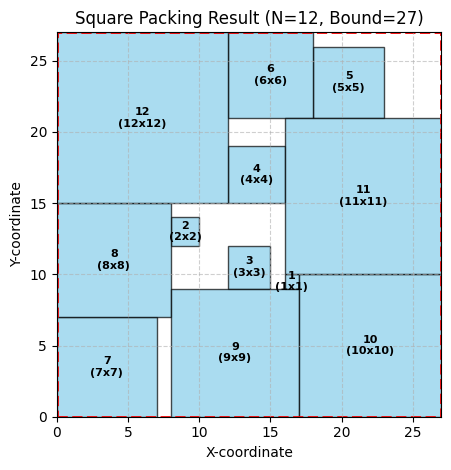

In [ ]:
# 結果の描画（matplotlib）
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_square_packing(sol, bound, title="Square Packing Result"):
    fig, ax = plt.subplots(1)
    ax.set_xlim(0, bound)
    ax.set_ylim(0, bound)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel("X-coordinate")
    ax.set_ylabel("Y-coordinate")
    ax.set_title(f"{title} (N={len(sol)}, Bound={bound})")
    ax.grid(True, linestyle='--', alpha=0.6)
    for sq in sol:
        x = sq['x']
        y = sq['y']
        size = sq['size']
        idx = sq['index']
        rect = patches.Rectangle((x, y), size, size, linewidth=1, edgecolor='black', facecolor='skyblue', alpha=0.7)
        ax.add_patch(rect)
        ax.text(x + size/2, y + size/2, f"{idx}\n({size}x{size})", color="black", ha="center", va="center", fontsize=8, weight="bold")
    outer_rect = patches.Rectangle((0, 0), bound, bound, linewidth=2, edgecolor='red', facecolor='none', linestyle='--')
    ax.add_patch(outer_rect)
    plt.tight_layout()
    plt.show()

# 例: 解を得た後に
if sol is not None and bound is not None:
    draw_square_packing(sol, bound)
else:
    print("描画できる解がありません")

# パラメータ一覧

```python3
# --- 全パラメータ一覧（SatParametersの全フィールド） ---
# solver.parameters.absolute_gap_limit = ...
# solver.parameters.add_cg_cuts = ...
# solver.parameters.add_clique_cuts = ...
# solver.parameters.add_lin_max_cuts = ...
# solver.parameters.add_lp_constraints_lazily = ...
# solver.parameters.add_mir_cuts = ...
# solver.parameters.add_objective_cut = ...
# solver.parameters.add_rlt_cuts = ...
# solver.parameters.add_zero_half_cuts = ...
# solver.parameters.also_bump_variables_in_conflict_reasons = ...
# solver.parameters.at_most_one_max_expansion_size = ...
# solver.parameters.auto_detect_greater_than_at_least_one_of = ...
# solver.parameters.binary_minimization_algorithm = ...
# solver.parameters.binary_search_num_conflicts = ...
# solver.parameters.blocking_restart_multiplier = ...
# solver.parameters.blocking_restart_window_size = ...
# solver.parameters.boolean_encoding_level = ...
# solver.parameters.catch_sigint_signal = ...
# solver.parameters.clause_activity_decay = ...
# solver.parameters.clause_cleanup_lbd_bound = ...
# solver.parameters.clause_cleanup_ordering = ...
# solver.parameters.clause_cleanup_period = ...
# solver.parameters.clause_cleanup_protection = ...
# solver.parameters.clause_cleanup_ratio = ...
# solver.parameters.clause_cleanup_target = ...
# solver.parameters.convert_intervals = ...
# solver.parameters.core_minimization_level = ...
# solver.parameters.count_assumption_levels_in_lbd = ...
# solver.parameters.cover_optimization = ...
# solver.parameters.cp_model_presolve = ...
# solver.parameters.cp_model_probing_level = ...
# solver.parameters.cp_model_use_sat_presolve = ...
# solver.parameters.cut_active_count_decay = ...
# solver.parameters.cut_cleanup_target = ...
# solver.parameters.cut_level = ...
# solver.parameters.cut_max_active_count_value = ...
# solver.parameters.debug_crash_if_presolve_breaks_hint = ...
# solver.parameters.debug_crash_on_bad_hint = ...
# solver.parameters.debug_max_num_presolve_operations = ...
# solver.parameters.debug_postsolve_with_full_solver = ...
# solver.parameters.default_restart_algorithms = ...
# solver.parameters.detect_linearized_product = ...
# solver.parameters.detect_table_with_cost = ...
# solver.parameters.disable_constraint_expansion = ...
# solver.parameters.diversify_lns_params = ...
# solver.parameters.encode_complex_linear_constraint_with_integer = ...
# solver.parameters.encode_cumulative_as_reservoir = ...
# solver.parameters.enumerate_all_solutions = ...
# solver.parameters.expand_alldiff_constraints = ...
# solver.parameters.expand_reservoir_constraints = ...
# solver.parameters.expand_reservoir_using_circuit = ...
# solver.parameters.exploit_all_lp_solution = ...
# solver.parameters.exploit_all_precedences = ...
# solver.parameters.exploit_best_solution = ...
# solver.parameters.exploit_integer_lp_solution = ...
# solver.parameters.exploit_objective = ...
# solver.parameters.exploit_relaxation_solution = ...
# solver.parameters.extra_subsolvers = ...
# solver.parameters.feasibility_jump_batch_dtime = ...
# solver.parameters.feasibility_jump_decay = ...
# solver.parameters.feasibility_jump_enable_restarts = ...
# solver.parameters.feasibility_jump_linearization_level = ...
# solver.parameters.feasibility_jump_max_expanded_constraint_size = ...
# solver.parameters.feasibility_jump_restart_factor = ...
# solver.parameters.feasibility_jump_var_perburbation_range_ratio = ...
# solver.parameters.feasibility_jump_var_randomization_probability = ...
# solver.parameters.fill_additional_solutions_in_response = ...
# solver.parameters.fill_tightened_domains_in_response = ...
# solver.parameters.filter_sat_postsolve_clauses = ...
# solver.parameters.filter_subsolvers = ...
# solver.parameters.find_big_linear_overlap = ...
# solver.parameters.find_multiple_cores = ...
# solver.parameters.fix_variables_to_their_hinted_value = ...
# solver.parameters.fp_rounding = ...
# solver.parameters.glucose_decay_increment = ...
# solver.parameters.glucose_decay_increment_period = ...
# solver.parameters.glucose_max_decay = ...
# solver.parameters.hint_conflict_limit = ...
# solver.parameters.ignore_names = ...
# solver.parameters.ignore_subsolvers = ...
# solver.parameters.infer_all_diffs = ...
# solver.parameters.initial_polarity = ...
# solver.parameters.initial_variables_activity = ...
# solver.parameters.inprocessing_dtime_ratio = ...
# solver.parameters.inprocessing_minimization_dtime = ...
# solver.parameters.inprocessing_minimization_use_all_orderings = ...
# solver.parameters.inprocessing_minimization_use_conflict_analysis = ...
# solver.parameters.inprocessing_probing_dtime = ...
# solver.parameters.instantiate_all_variables = ...
# solver.parameters.interleave_batch_size = ...
# solver.parameters.interleave_search = ...
# solver.parameters.keep_all_feasible_solutions_in_presolve = ...
# solver.parameters.keep_symmetry_in_presolve = ...
# solver.parameters.lb_relax_num_workers_threshold = ...
# solver.parameters.linear_split_size = ...
# solver.parameters.linearization_level = ...
# solver.parameters.lns_initial_deterministic_limit = ...
# solver.parameters.lns_initial_difficulty = ...
# solver.parameters.log_prefix = ...
# solver.parameters.log_search_progress = ...
# solver.parameters.log_subsolver_statistics = ...
# solver.parameters.log_to_response = ...
# solver.parameters.log_to_stdout = ...
# solver.parameters.lp_dual_tolerance = ...
# solver.parameters.lp_primal_tolerance = ...
# solver.parameters.max_all_diff_cut_size = ...
# solver.parameters.max_alldiff_domain_size = ...
# solver.parameters.max_clause_activity_value = ...
# solver.parameters.max_consecutive_inactive_count = ...
# solver.parameters.max_cut_rounds_at_level_zero = ...
# solver.parameters.max_deterministic_time = ...
# solver.parameters.max_domain_size_when_encoding_eq_neq_constraints = ...
# solver.parameters.max_integer_rounding_scaling = ...
# solver.parameters.max_lin_max_size_for_expansion = ...
# solver.parameters.max_memory_in_mb = ...
# solver.parameters.max_num_cuts = ...
# solver.parameters.max_num_deterministic_batches = ...
# solver.parameters.max_num_intervals_for_timetable_edge_finding = ...
# solver.parameters.max_number_of_conflicts = ...
# solver.parameters.max_pairs_pairwise_reasoning_in_no_overlap_2d = ...
# solver.parameters.max_presolve_iterations = ...
# solver.parameters.max_sat_assumption_order = ...
# solver.parameters.max_sat_reverse_assumption_order = ...
# solver.parameters.max_sat_stratification = ...
# solver.parameters.max_size_to_create_precedence_literals_in_disjunctive = ...
# solver.parameters.max_time_in_seconds = ...
# solver.parameters.max_variable_activity_value = ...
# solver.parameters.maximum_regions_to_split_in_disconnected_no_overlap_2d = ...
# solver.parameters.merge_at_most_one_work_limit = ...
# solver.parameters.merge_no_overlap_work_limit = ...
# solver.parameters.min_orthogonality_for_lp_constraints = ...
# solver.parameters.minimization_algorithm = ...
# solver.parameters.minimize_reduction_during_pb_resolution = ...
# solver.parameters.minimize_shared_clauses = ...
# solver.parameters.mip_automatically_scale_variables = ...
# solver.parameters.mip_check_precision = ...
# solver.parameters.mip_compute_true_objective_bound = ...
# solver.parameters.mip_drop_tolerance = ...
# solver.parameters.mip_max_activity_exponent = ...
# solver.parameters.mip_max_bound = ...
# solver.parameters.mip_max_valid_magnitude = ...
# solver.parameters.mip_presolve_level = ...
# solver.parameters.mip_scale_large_domain = ...
# solver.parameters.mip_treat_high_magnitude_bounds_as_infinity = ...
# solver.parameters.mip_var_scaling = ...
# solver.parameters.mip_wanted_precision = ...
# solver.parameters.name = ...
# solver.parameters.new_constraints_batch_size = ...
# solver.parameters.new_linear_propagation = ...
# solver.parameters.no_overlap_2d_boolean_relations_limit = ...
# solver.parameters.num_conflicts_before_strategy_changes = ...
# solver.parameters.num_full_subsolvers = ...
# solver.parameters.num_search_workers = ...
# solver.parameters.num_violation_ls = ...
# solver.parameters.num_workers = ...
# solver.parameters.only_add_cuts_at_level_zero = ...
# solver.parameters.only_solve_ip = ...
# solver.parameters.optimize_with_core = ...
# solver.parameters.optimize_with_lb_tree_search = ...
# solver.parameters.optimize_with_max_hs = ...
# solver.parameters.pb_cleanup_increment = ...
# solver.parameters.pb_cleanup_ratio = ...
# solver.parameters.permute_presolve_constraint_order = ...
# solver.parameters.permute_variable_randomly = ...
# solver.parameters.polarity_exploit_ls_hints = ...
# solver.parameters.polarity_rephase_increment = ...
# solver.parameters.polish_lp_solution = ...
# solver.parameters.preferred_variable_order = ...
# solver.parameters.presolve_blocked_clause = ...
# solver.parameters.presolve_bva_threshold = ...
# solver.parameters.presolve_bve_clause_weight = ...
# solver.parameters.presolve_bve_threshold = ...
# solver.parameters.presolve_extract_integer_enforcement = ...
# solver.parameters.presolve_inclusion_work_limit = ...
# solver.parameters.presolve_probing_deterministic_time_limit = ...
# solver.parameters.presolve_substitution_level = ...
# solver.parameters.presolve_use_bva = ...
# solver.parameters.probing_deterministic_time_limit = ...
# solver.parameters.probing_num_combinations_limit = ...
# solver.parameters.propagation_loop_detection_factor = ...
# solver.parameters.pseudo_cost_reliability_threshold = ...
# solver.parameters.push_all_tasks_toward_start = ...
# solver.parameters.random_branches_ratio = ...
# solver.parameters.random_polarity_ratio = ...
# solver.parameters.random_seed = ...
# solver.parameters.randomize_search = ...
# solver.parameters.relative_gap_limit = ...
# solver.parameters.remove_fixed_variables_early = ...
# solver.parameters.repair_hint = ...
# solver.parameters.restart_algorithms = ...
# solver.parameters.restart_dl_average_ratio = ...
# solver.parameters.restart_lbd_average_ratio = ...
# solver.parameters.restart_period = ...
# solver.parameters.restart_running_window_size = ...
# solver.parameters.root_lp_iterations = ...
# solver.parameters.routing_cut_dp_effort = ...
# solver.parameters.routing_cut_max_infeasible_path_length = ...
# solver.parameters.routing_cut_subset_size_for_binary_relation_bound = ...
# solver.parameters.routing_cut_subset_size_for_exact_binary_relation_bound = ...
# solver.parameters.routing_cut_subset_size_for_shortest_paths_bound = ...
# solver.parameters.routing_cut_subset_size_for_tight_binary_relation_bound = ...
# solver.parameters.save_lp_basis_in_lb_tree_search = ...
# solver.parameters.search_branching = ...
# solver.parameters.search_random_variable_pool_size = ...
# solver.parameters.share_binary_clauses = ...
# solver.parameters.share_glue_clauses = ...
# solver.parameters.share_glue_clauses_dtime = ...
# solver.parameters.share_level_zero_bounds = ...
# solver.parameters.share_objective_bounds = ...
# solver.parameters.shared_tree_balance_tolerance = ...
# solver.parameters.shared_tree_max_nodes_per_worker = ...
# solver.parameters.shared_tree_num_workers = ...
# solver.parameters.shared_tree_open_leaves_per_worker = ...
# solver.parameters.shared_tree_split_strategy = ...
# solver.parameters.shared_tree_worker_enable_phase_sharing = ...
# solver.parameters.shared_tree_worker_enable_trail_sharing = ...
# solver.parameters.shared_tree_worker_min_restarts_per_subtree = ...
# solver.parameters.shaving_deterministic_time_in_probing_search = ...
# solver.parameters.shaving_search_deterministic_time = ...
# solver.parameters.shaving_search_threshold = ...
# solver.parameters.solution_pool_size = ...
# solver.parameters.stop_after_first_solution = ...
# solver.parameters.stop_after_presolve = ...
# solver.parameters.stop_after_root_propagation = ...
# solver.parameters.strategy_change_increase_ratio = ...
# solver.parameters.subsolver_params = ...
# solver.parameters.subsolvers = ...
# solver.parameters.subsumption_during_conflict_analysis = ...
# solver.parameters.symmetry_detection_deterministic_time_limit = ...
# solver.parameters.symmetry_level = ...
# solver.parameters.table_compression_level = ...
# solver.parameters.use_absl_random = ...
# solver.parameters.use_all_different_for_circuit = ...
# solver.parameters.use_area_energetic_reasoning_in_no_overlap_2d = ...
# solver.parameters.use_blocking_restart = ...
# solver.parameters.use_combined_no_overlap = ...
# solver.parameters.use_conservative_scale_overload_checker = ...
# solver.parameters.use_disjunctive_constraint_in_cumulative = ...
# solver.parameters.use_dual_scheduling_heuristics = ...
# solver.parameters.use_dynamic_precedence_in_cumulative = ...
# solver.parameters.use_dynamic_precedence_in_disjunctive = ...
# solver.parameters.use_energetic_reasoning_in_no_overlap_2d = ...
# solver.parameters.use_erwa_heuristic = ...
# solver.parameters.use_exact_lp_reason = ...
# solver.parameters.use_extended_probing = ...
# solver.parameters.use_feasibility_jump = ...
# solver.parameters.use_feasibility_pump = ...
# solver.parameters.use_hard_precedences_in_cumulative = ...
# solver.parameters.use_implied_bounds = ...
# solver.parameters.use_lb_relax_lns = ...
# solver.parameters.use_linear3_for_no_overlap_2d_precedences = ...
# solver.parameters.use_lns = ...
# solver.parameters.use_lns_only = ...
# solver.parameters.use_ls_only = ...
# solver.parameters.use_objective_lb_search = ...
# solver.parameters.use_objective_shaving_search = ...
# solver.parameters.use_optimization_hints = ...
# solver.parameters.use_optional_variables = ...
# solver.parameters.use_overload_checker_in_cumulative = ...
# solver.parameters.use_pb_resolution = ...
# solver.parameters.use_phase_saving = ...
# solver.parameters.use_precedences_in_disjunctive_constraint = ...
# solver.parameters.use_probing_search = ...
# solver.parameters.use_rins_lns = ...
# solver.parameters.use_sat_inprocessing = ...
# solver.parameters.use_shared_tree_search = ...
# solver.parameters.use_strong_propagation_in_disjunctive = ...
# solver.parameters.use_symmetry_in_lp = ...
# solver.parameters.use_timetable_edge_finding_in_cumulative = ...
# solver.parameters.use_timetabling_in_no_overlap_2d = ...
# solver.parameters.use_try_edge_reasoning_in_no_overlap_2d = ...
# solver.parameters.variable_activity_decay = ...
# solver.parameters.variables_shaving_level = ...
# solver.parameters.violation_ls_compound_move_probability = ...
# solver.parameters.violation_ls_perturbation_period = ...
```

In [ ]:
# 利用可能な制約（Add...メソッド）とパラメータの一覧表示
from ortools.sat.python import cp_model

print("=== Add... メソッド一覧 ===")
model = cp_model.CpModel()
add_methods = sorted([m for m in dir(model) if m.startswith('Add')])
for m in add_methods:
    print(m)

print("\n=== ソルバーパラメータ一覧 (solver.parameters) ===")
solver = cp_model.CpSolver()
# protobufのフィールド一覧を取得
parameters = sorted([f.name for f in solver.parameters.DESCRIPTOR.fields])
for p in parameters:
    print(f"solver.parameters.{p}")

記載されていない Add... メソッド数: 9
--- 一覧 ---
AddAssumption
AddAssumptions
AddAtLeastOne
AddAtMostOne
AddCircuit
AddHint
AddLinearConstraint
AddLinearExpressionInDomain
AddMultipleCircuit
